In [ ]:
# unzip folder

import zipfile
import os

def unzip(path, output=None):
  if output is None:
    dir = os.path.dirname(path)
  with zipfile.ZipFile(path, 'r') as zip_ref:
      zip_ref.extractall(dir)

In [ ]:
SEED = 2025

In [ ]:
#@title Download datasets
!pip install gdown # Install gdown
import gdown # Import gdown

FILE_ID_DATASET = '1ORO25C8ogbVsjrxtM6G7QDRZ61r7u10F'

if not os.path.isdir('./datasets'):
  !mkdir datasets
  # Use gdown to download the file by ID
  gdown.download(id=FILE_ID_DATASET, output='./datasets/dataset_merged.zip', quiet=False)
  unzip('./datasets/dataset_merged.zip')

Downloading...
From (original): https://drive.google.com/uc?id=1ORO25C8ogbVsjrxtM6G7QDRZ61r7u10F
From (redirected): https://drive.google.com/uc?id=1ORO25C8ogbVsjrxtM6G7QDRZ61r7u10F&confirm=t&uuid=53aef22d-ae1f-4479-bd99-6d02579a91c6
To: /content/datasets/dataset_merged.zip
100%|██████████| 1.80G/1.80G [00:32<00:00, 55.5MB/s]


In [ ]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/112.6 GB disk)


In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.0 MB/s eta 0:00:00


In [ ]:
dataset_path = './datasets/dataset_ball_merged'
with open(os.path.join(dataset_path, 'data.yaml'), 'w') as file:
  file.write(f"path: {os.path.abspath(dataset_path)}\ntrain: images/train\nval: images/val\ntest: images/test\nnames:\n  0: ball")

In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11n-seg.pt")  # load a pretrained model (recommended for training)

In [ ]:
#@title Fix errors in dataset

FIX = False

if FIX:
  W = 1920
  H = 1080
  # Change all labels from 32 to 0 in label.txt files
  for split in ['train', 'val', 'test']:
      labels_dir = os.path.join(dataset_path, 'labels', split)
      if os.path.exists(labels_dir):
          for filename in os.listdir(labels_dir):
              if filename.endswith('.txt'):
                  filepath = os.path.join(labels_dir, filename)
                  with open(filepath, 'r') as f:
                      lines = f.readlines()

                  modified_lines = []
                  for line in lines:
                      parts = line.strip().split()
                      if parts:
                          parts[0] = '0'
                          for i in range(1, len(parts)):
                            if i%2:
                              parts[i] = f'{float(parts[i])*H/W:.6f}'
                            else:
                              parts[i] = f'{float(parts[i])*W/H:.6f}'
                          modified_lines.append(' '.join(parts) + '\n')
                      else:
                          modified_lines.append(line)

                  with open(filepath, 'w') as f:
                      f.writelines(modified_lines)


## Fine tune model

In [ ]:
# Callback para congelar las primeras freeze_n capas durante las primeras freeze_epochs epochs
class FreezeWarmupCallback:
    def __init__(self, freeze_n=10, freeze_epochs=5):
        self.freeze_n = freeze_n
        self.freeze_epochs = freeze_epochs
        self.frozen = False

    def on_train_start(self, trainer):
        # Congelar las primeras N capas
        self.layers = list(trainer.model.model.children())[:self.freeze_n]
        for layer in self.layers:
            for p in layer.parameters():
                p.requires_grad = False
        self.frozen = True
        # print(f"[FreezeWarmup] {self.freeze_n} capas congeladas durante {self.freeze_epochs} épocas.")

    def on_epoch_end(self, trainer):
        # A partir de la época freeze_epochs → descongelar
        if self.frozen and trainer.epoch + 1 >= self.freeze_epochs:
            for layer in self.layers:
                for p in layer.parameters():
                    p.requires_grad = True
            self.frozen = False
            # print(f"[FreezeWarmup] Capas descongeladas a partir de la época {trainer.epoch + 1}.")

callback = lambda freeze_n, freeze_epochs: FreezeWarmupCallback(
    freeze_n=freeze_n,            # número de capas a congelar
    freeze_epochs=freeze_epochs   # número de épocas durante las cuales estarán congeladas
)

In [ ]:
#@title Búsqueda de hiperparámetros con skopt (unused)
from ultralytics import YOLO
from pathlib import Path
import json
from skopt import gp_minimize
import pandas as pd
from skopt.space import Real, Integer, Categorical

search_space = [
    Real(1e-6, 1e-3, name="lr0"),
    Real(1e-5, 2e-3, name="weight_decay"),
    Categorical([0, 10], name="freeze"),
    Categorical([50], name="epochs"), # 50, 100, 150
    # Categorical([5, 10], name="freeze_epochs"),
]

def objective(params):
    lr0, weight_decay, freeze, epochs = params # , freeze_epochs = params

    run_name = f"bo_lr{lr0:.2e}_wd{weight_decay:.1e}_fr{freeze}ep{epochs}" # _fe{freeze_epochs}"

    model = YOLO("yolo11n-seg.pt")

    # Callback para freeze durante warmup
    # This callback is no longer used as 'callbacks' is not a valid argument for model.train()
    # callback = FreezeWarmupCallback(
    #     freeze_n=freeze,
    #     freeze_epochs=freeze_epochs
    # )

    results = model.train(
        data="./datasets/dataset_ball_merged/data.yaml",
        lr0=lr0,
        weight_decay=weight_decay,
        epochs=epochs,
        freeze=freeze, # This argument from the search space will still be applied
        name=run_name,
        project="bayes_search_yolo11",
        # callbacks=[callback],
        verbose=False
    )

    # Cargar métrica final desde el metrics.json del run
    metrics_file = Path(f"bayes_search_yolo11/{run_name}/metrics.json")

    if not metrics_file.exists():
        return 0  # penalización

    metrics = json.load(open(metrics_file))
    mAP = metrics.get("mAP50_mask", 0)

    return -mAP  # bayes opt minimiza


def save_results(results_bo):
  columns = ["lr0", "weight_decay", "freeze", "freeze_epochs", "epochs", "score"]
  rows = []

  for params, score in zip(results_bo.x_iters, results_bo.func_vals):
      rows.append(params + [-score])  # score positivo = mejor mAP

  df = pd.DataFrame(rows, columns=columns)
  df.to_csv("bayes_search_results.csv", index=False)
  print("Resultados guardados en bayes_search_results.csv")

  best_params = results_bo.x
  best_score = -results_bo.fun

  print("\n===== Mejor combinación encontrada =====")
  print(best_params)


def get_best_model_path():
    df = pd.read_csv("bayes_search_results.csv")
    best_row = df.loc[df["score"].idxmax()]

    run_name = f"bo_lr{best_row.lr0:.2e}_wd{best_row.weight_decay:.1e}_fr{int(best_row.freeze)}_fe{int(best_row.freeze_epochs)}_ep{int(best_row.epochs)}"
    return Path(f"bayes_search_yolo11/{run_name}/weights/best.pt")

# results_bo = gp_minimize(func=objective, dimensions=search_space, n_calls=10, random_state=SEED, verbose=True)
# save_results(results_bo)
# best_model_path = get_best_model_path()
# print("Mejor modelo:", best_model_path)
# best_model = YOLO(best_model_path)

In [ ]:
#@title Búsqueda de hiperparámetros con un grid pequeño
import itertools

grid = {
    "epochs": [50],
    "freeze": [0, 10]
}

keys = list(grid.keys())
values = list(grid.values())

configs = [dict(zip(keys, combo)) for combo in itertools.product(*values)]

results = dict()

for config in configs:

    run_name = "_".join(f"{k}{v}" for k, v in config.items())

    model = YOLO("yolo11n-seg.pt")

    results[run_name] = model.train(
        data="./datasets/dataset_ball_merged/data.yaml",
        name=run_name,
        imgsz=640,
        batch=64,
        workers=16,
        **config
    )

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/dataset_ball_merged/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=epochs50_freeze0, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

In [ ]:
# Seleccionar el mejor modelo (métrica:maP50-95)
best_run = min(results, key=lambda k: results[k].results_dict["metrics/mAP50-95(B)"])

print("Mejor configuración:", best_run)
print("Resultados:", results[best_run])

model = YOLO(f"/content/runs/segment/{best_run}/weights/best.pt")

Mejor configuración: epochs50_freeze10
Resultados: ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fafb181ffb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,  

In [ ]:
#     space={
#         "lr0": [0.0005, 0.001, 0.002, 0.005],
#         # "weight_decay": [0.0001, 0.0005, 0.001, 0.002],
#         # "warmup_epochs": [2, 3, 5],
#         # "optimizer": ["AdamW", "SGD"],
#         "freeze": [0, 10, 20],
#         "epochs": [40, 60, 100],
#         "callbacks": [callback(0, 0), callback(10, 10), callback(10, 20), (10, 40)]
#     }
"""
import itertools

space={
  "lr0": (1e-6, 1e-3),
  "weight_decay": (0.0001, 0.002),
  # "warmup_epochs": [2, 3, 5],
  "freeze": (0, 20), # Changed from tuple to list of discrete values
  "epochs": (50, 300) # Changed from tuple to list of discrete values
}

freeze_values = [0, 10, 20]
freeze_epochs_values = [10, 20, 40]
epochs_values = [50, 150]

for i, (freeze_n, freeze_epochs, total_epochs) in enumerate(configs):

    run_name = f"freeze{freeze_n}_fe{freeze_epochs}_ep{total_epochs}"

    model = YOLO("yolo11n-seg.pt")

    results = model.tune(
        data="./datasets/dataset_ball_merged/data.yaml",
        space=space,         # SOLO los hiperparámetros continuos
        optimizer="AdamW",
        iterations=20,       # tuner interno
        name=run_name,
        epochs=total_epochs,
        freeze=freeze_n,     # el tuner NO modifica esto
        # si usas warmup freezing, aquí va el callback
    )
  """

In [ ]:
# results = model.train(data="./datasets/dataset_ball_merged/data.yaml", epochs=10, imgsz=640, batch=64, workers=16)

In [ ]:
# Run inference on some test images
import random

test_images_dir = os.path.join(dataset_path, 'images', 'test')

# Get a list of all image files in the test directory
image_files = [os.path.join(test_images_dir, f) for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Select 10 random images from the test set
# Ensure there are at least 10 images to select, otherwise select all available
num_images_to_predict = min(10, len(image_files))
selected_images = random.sample(image_files, num_images_to_predict)

print(f"Running inference on {num_images_to_predict} test images...")

# Run inference on the selected images
# The 'show=True' argument will display the results in the notebook
results = model.predict(source=selected_images, save=True, show=False, name='segmentation_results')

Running inference on 10 test images...

0: 384x640 (no detections), 6.1ms
1: 384x640 1 ball, 6.1ms
2: 384x640 1 ball, 6.1ms
3: 384x640 1 ball, 6.1ms
4: 384x640 (no detections), 6.1ms
5: 384x640 (no detections), 6.1ms
6: 384x640 1 ball, 6.1ms
7: 384x640 1 ball, 6.1ms
8: 384x640 1 ball, 6.1ms
9: 384x640 1 ball, 6.1ms
Speed: 2.7ms preprocess, 6.1ms inference, 7.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/segment/segmentation_results


Displaying segmented images from: /content/runs/segment/segmentation_results
Showing 5 segmented images:


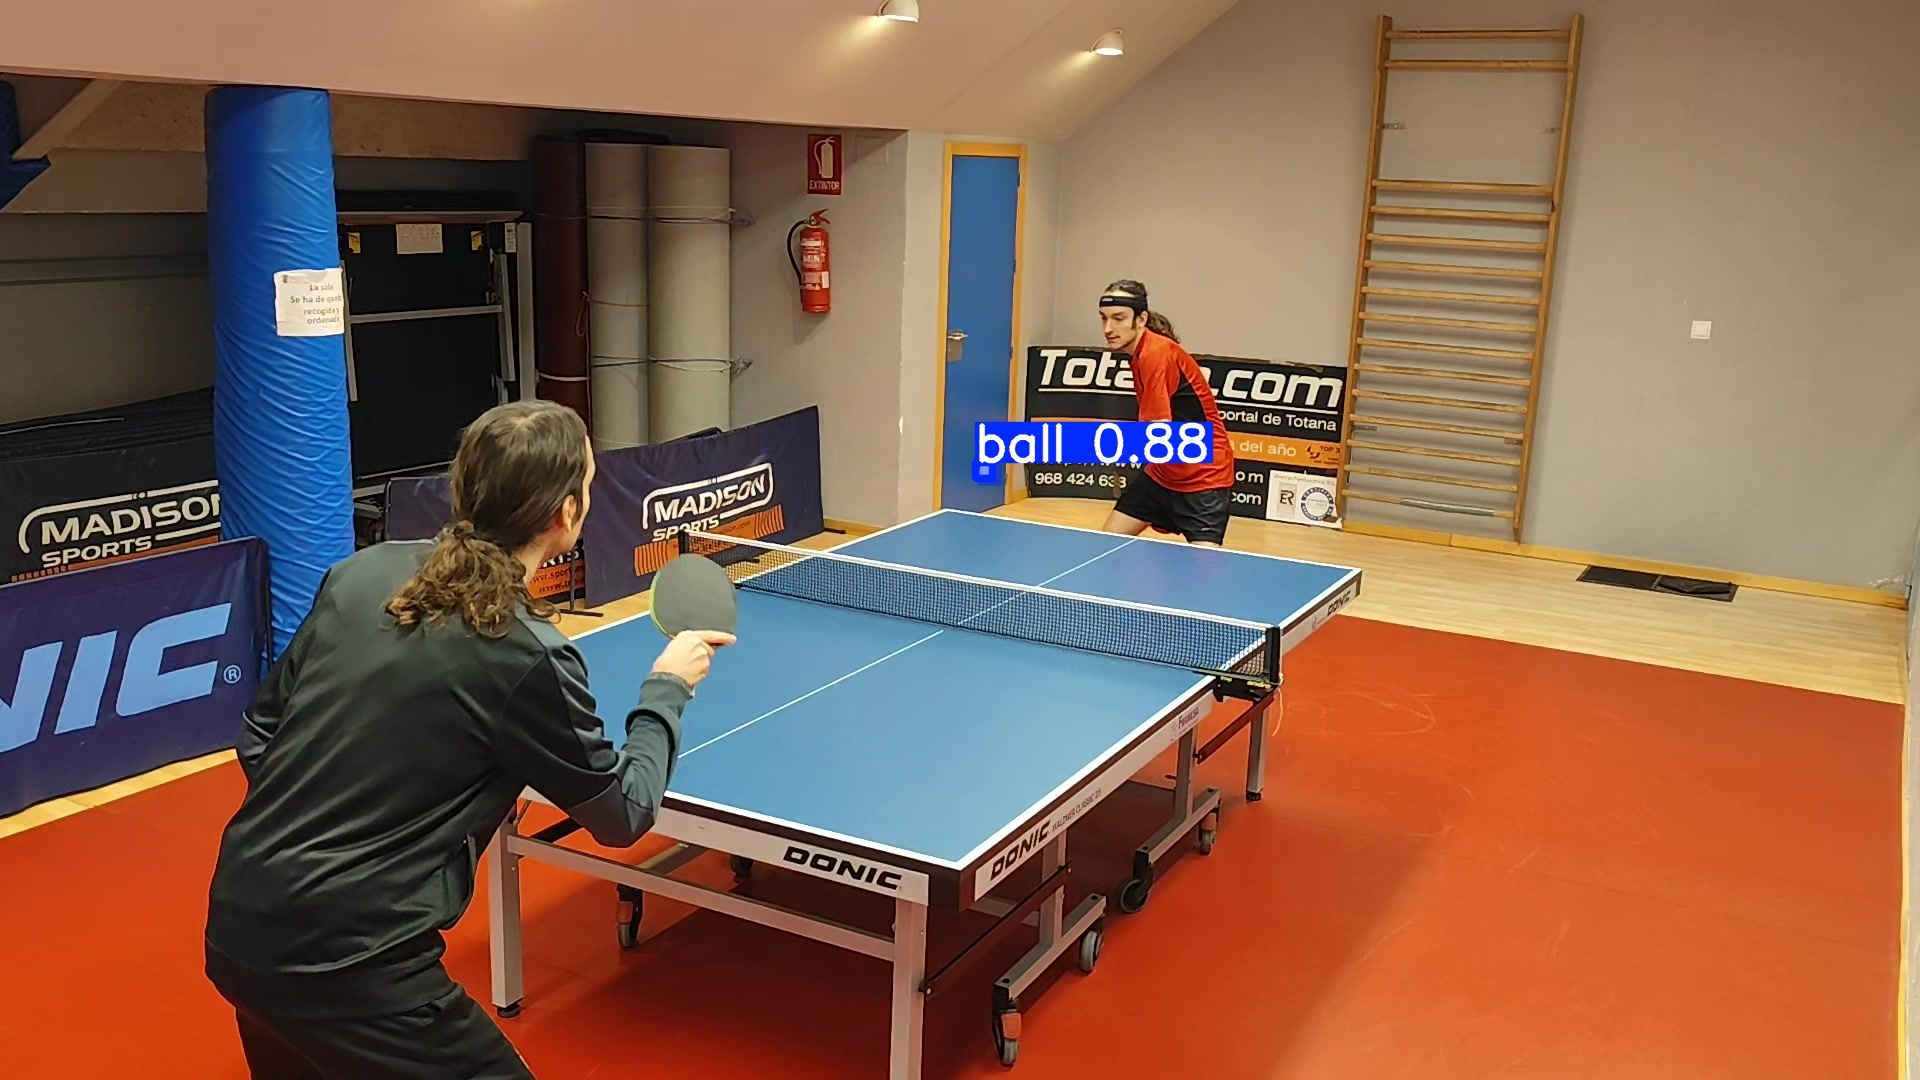

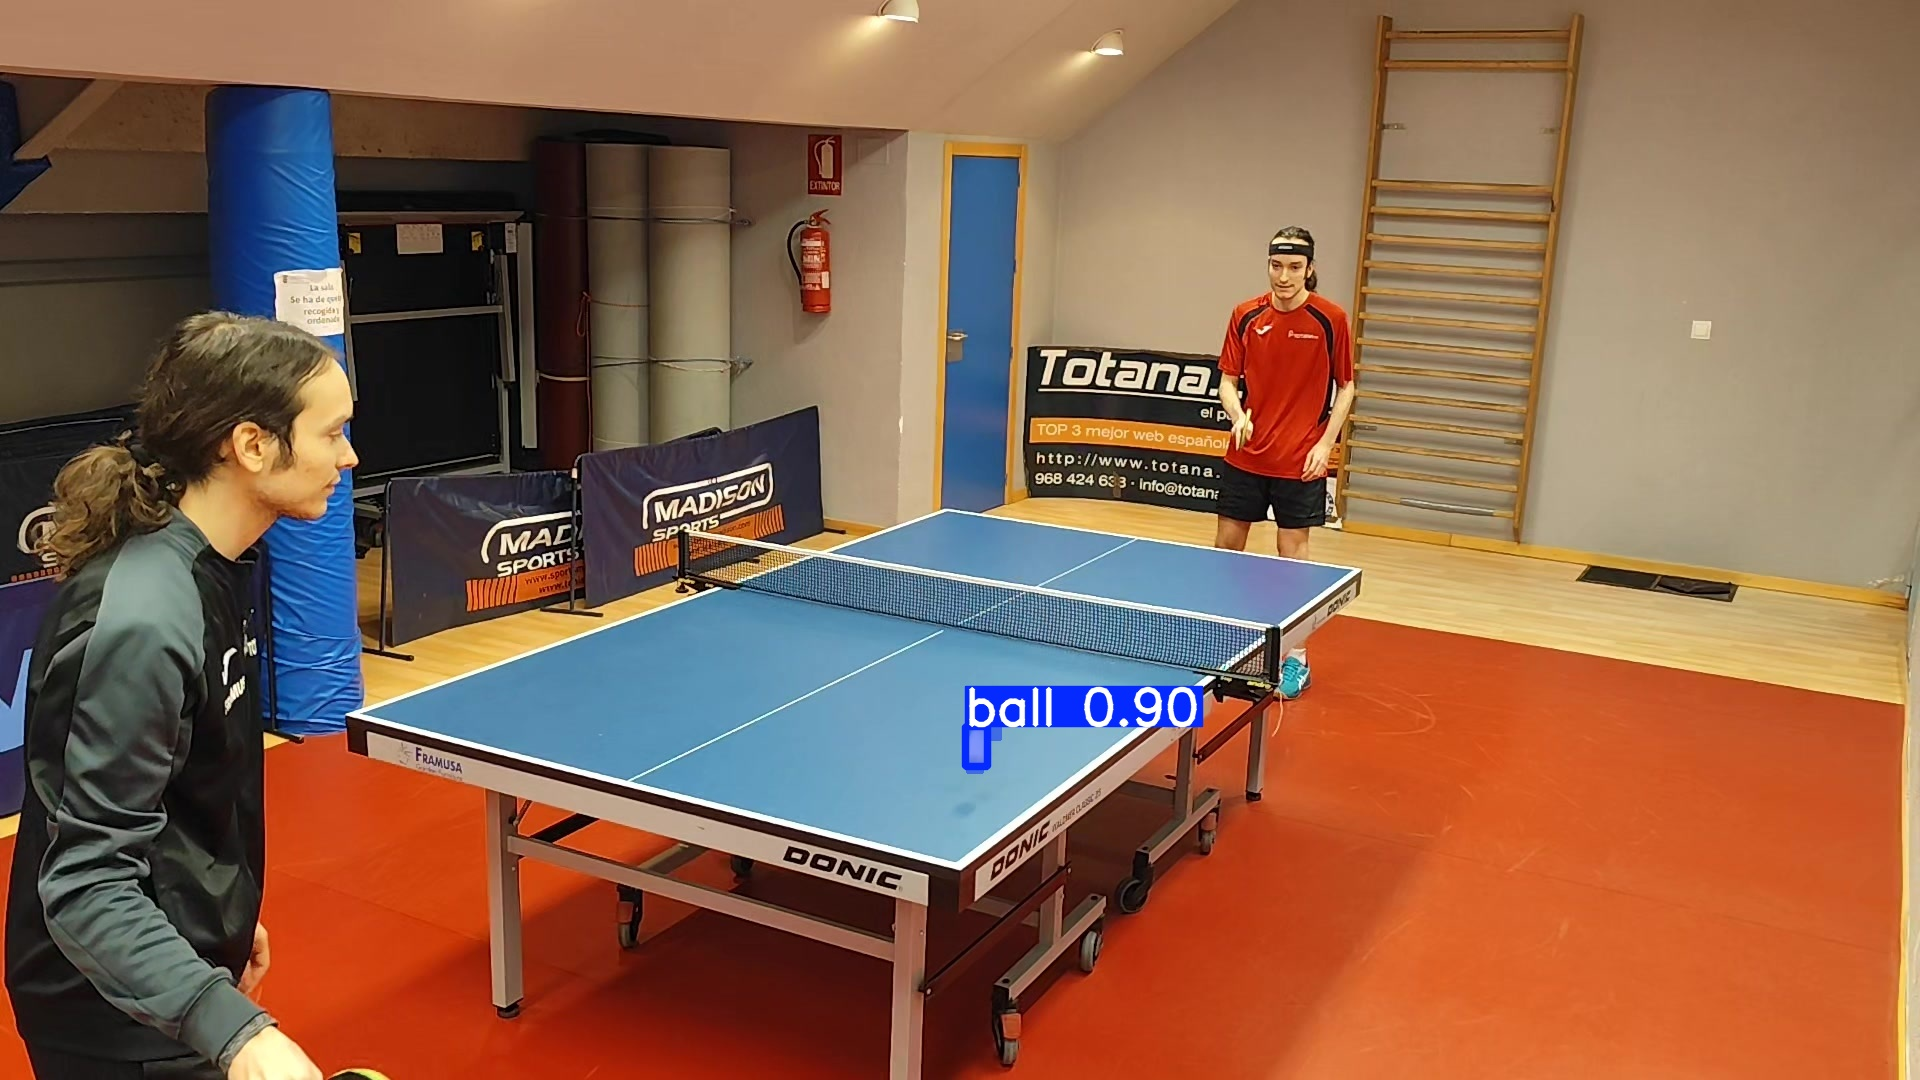

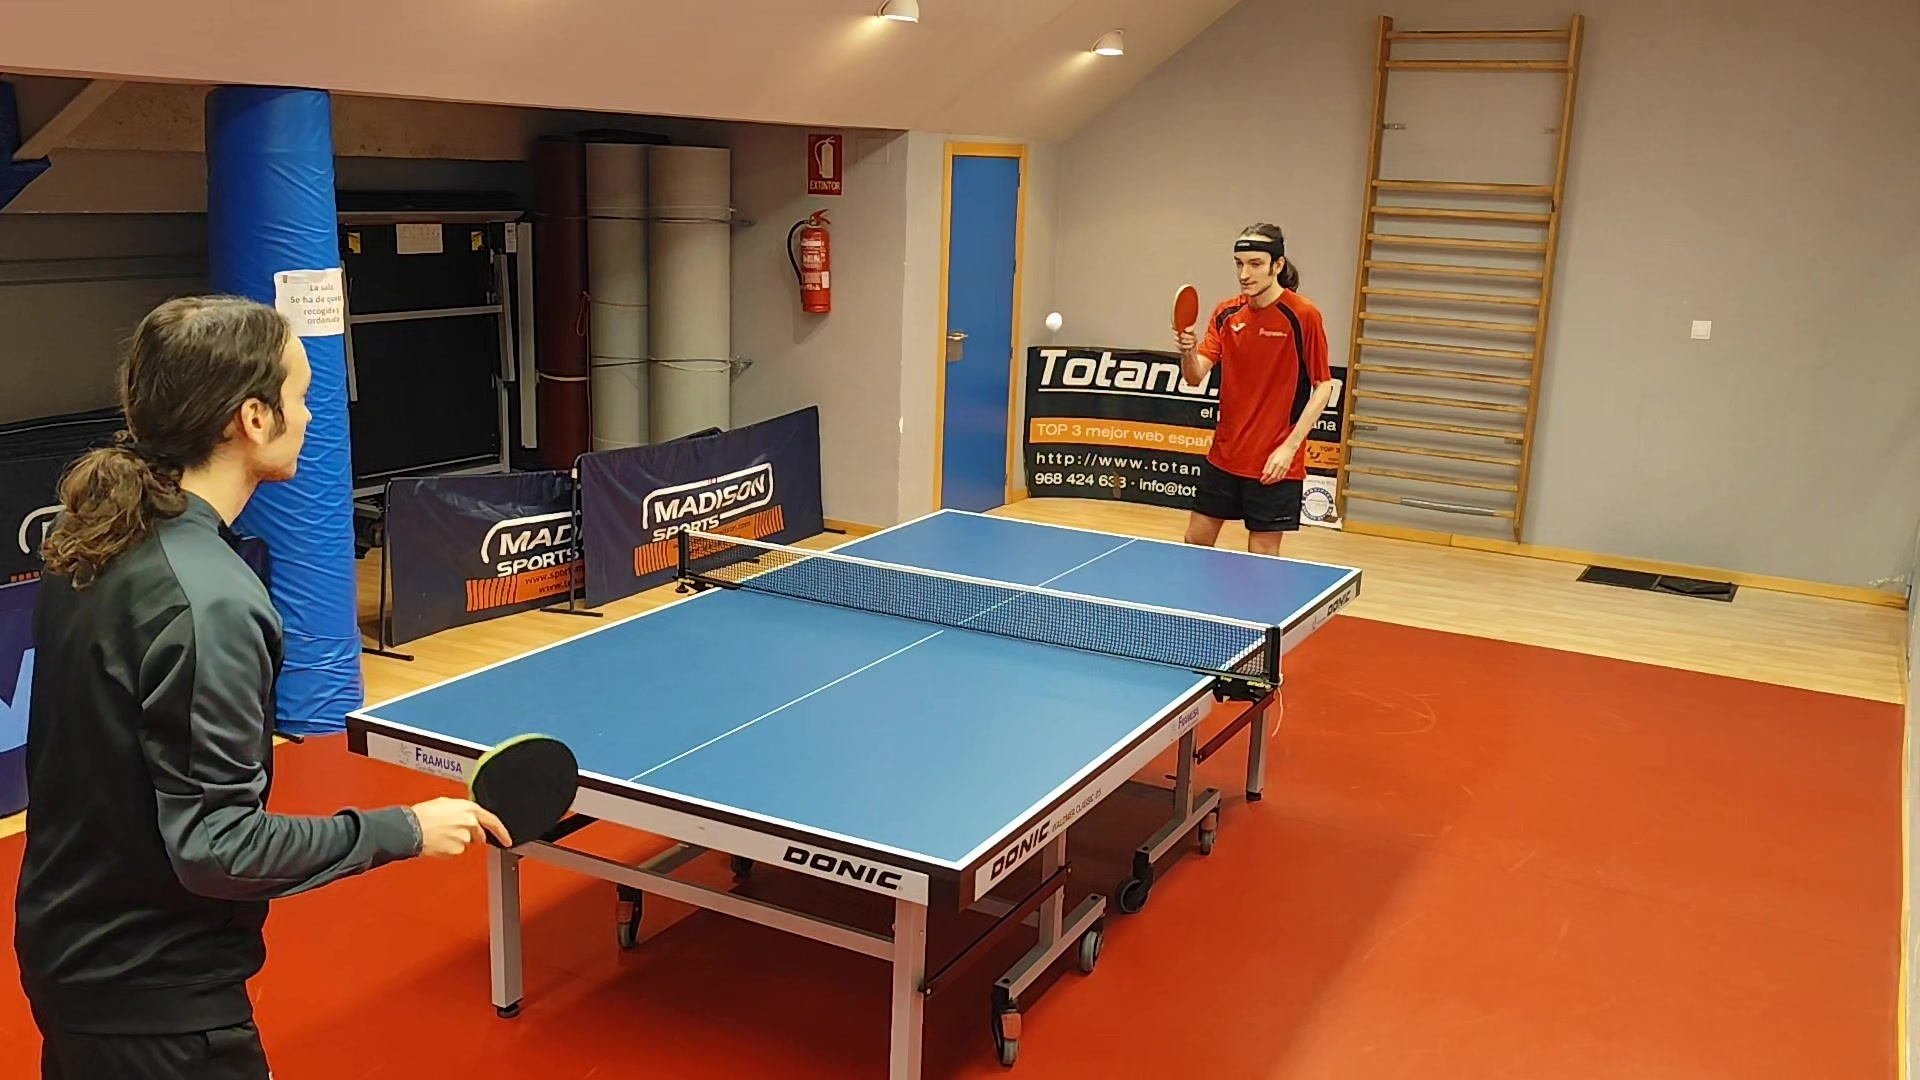

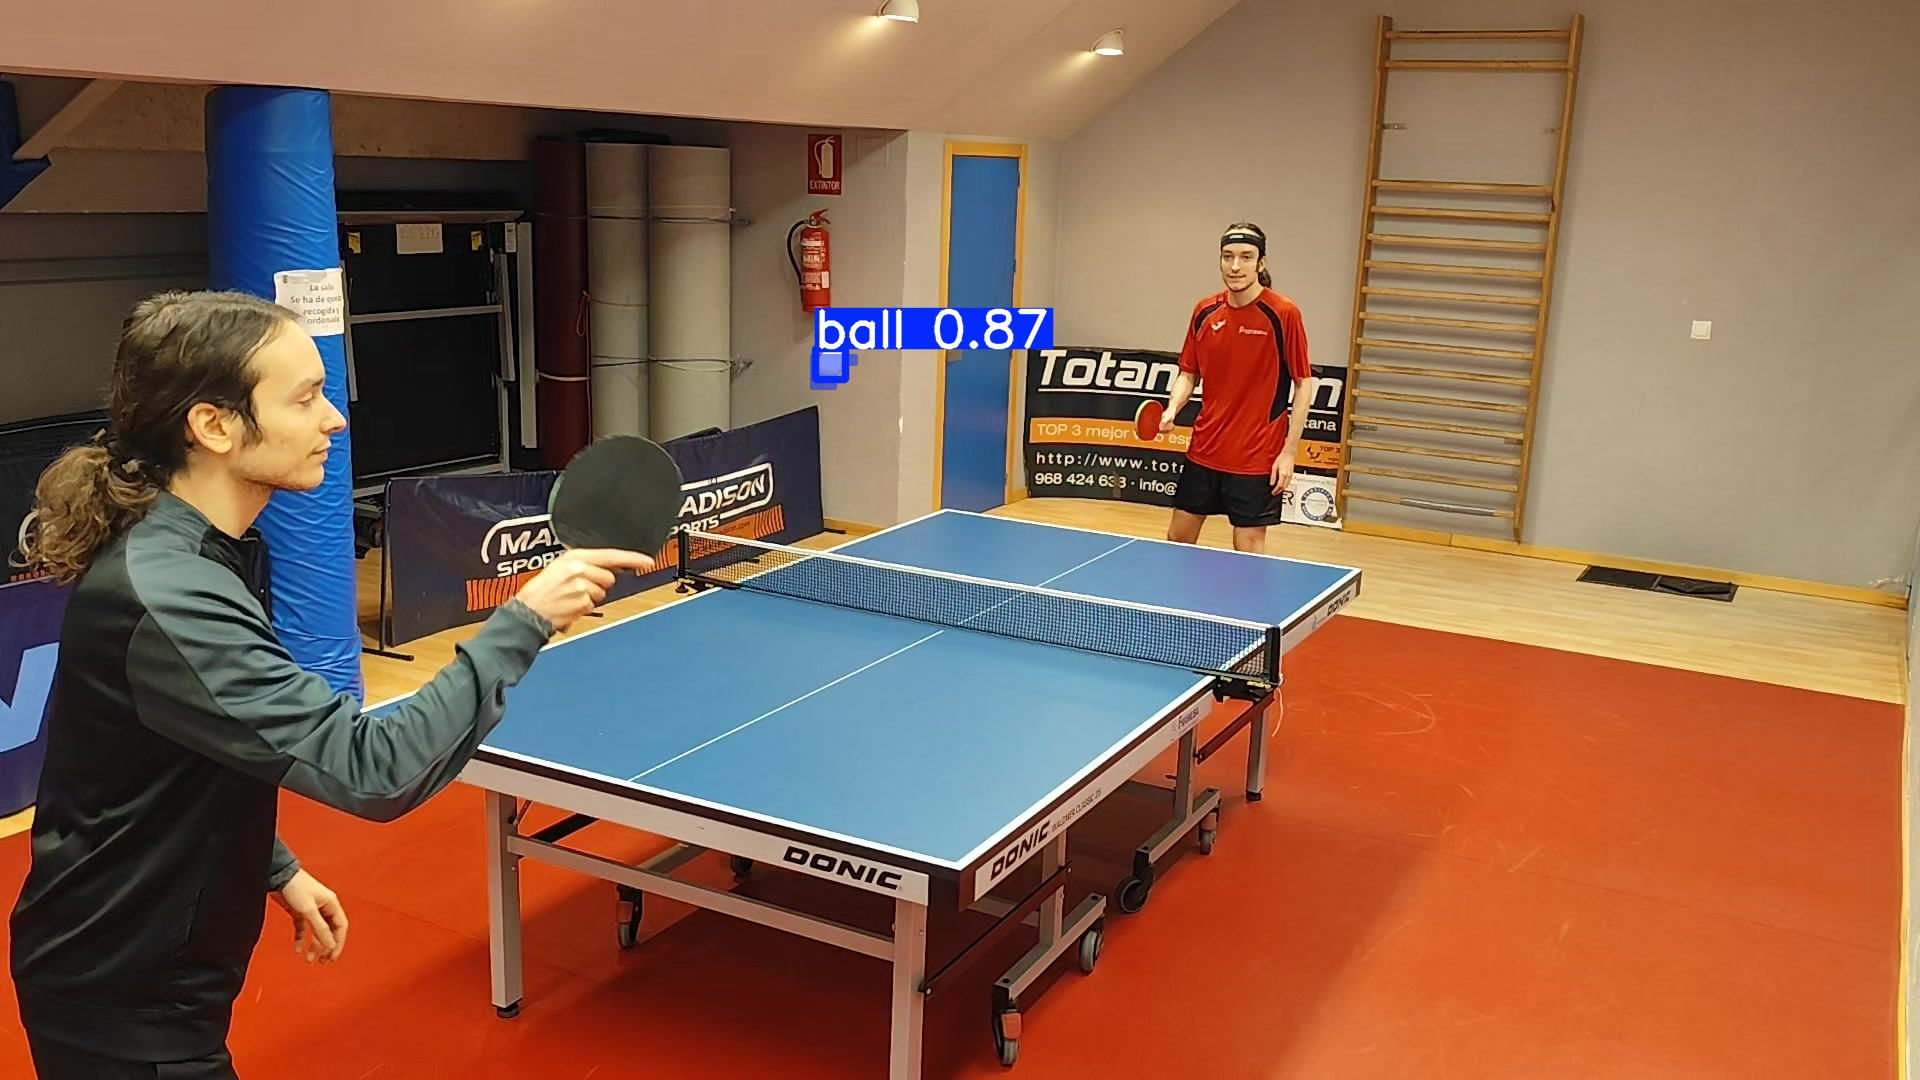

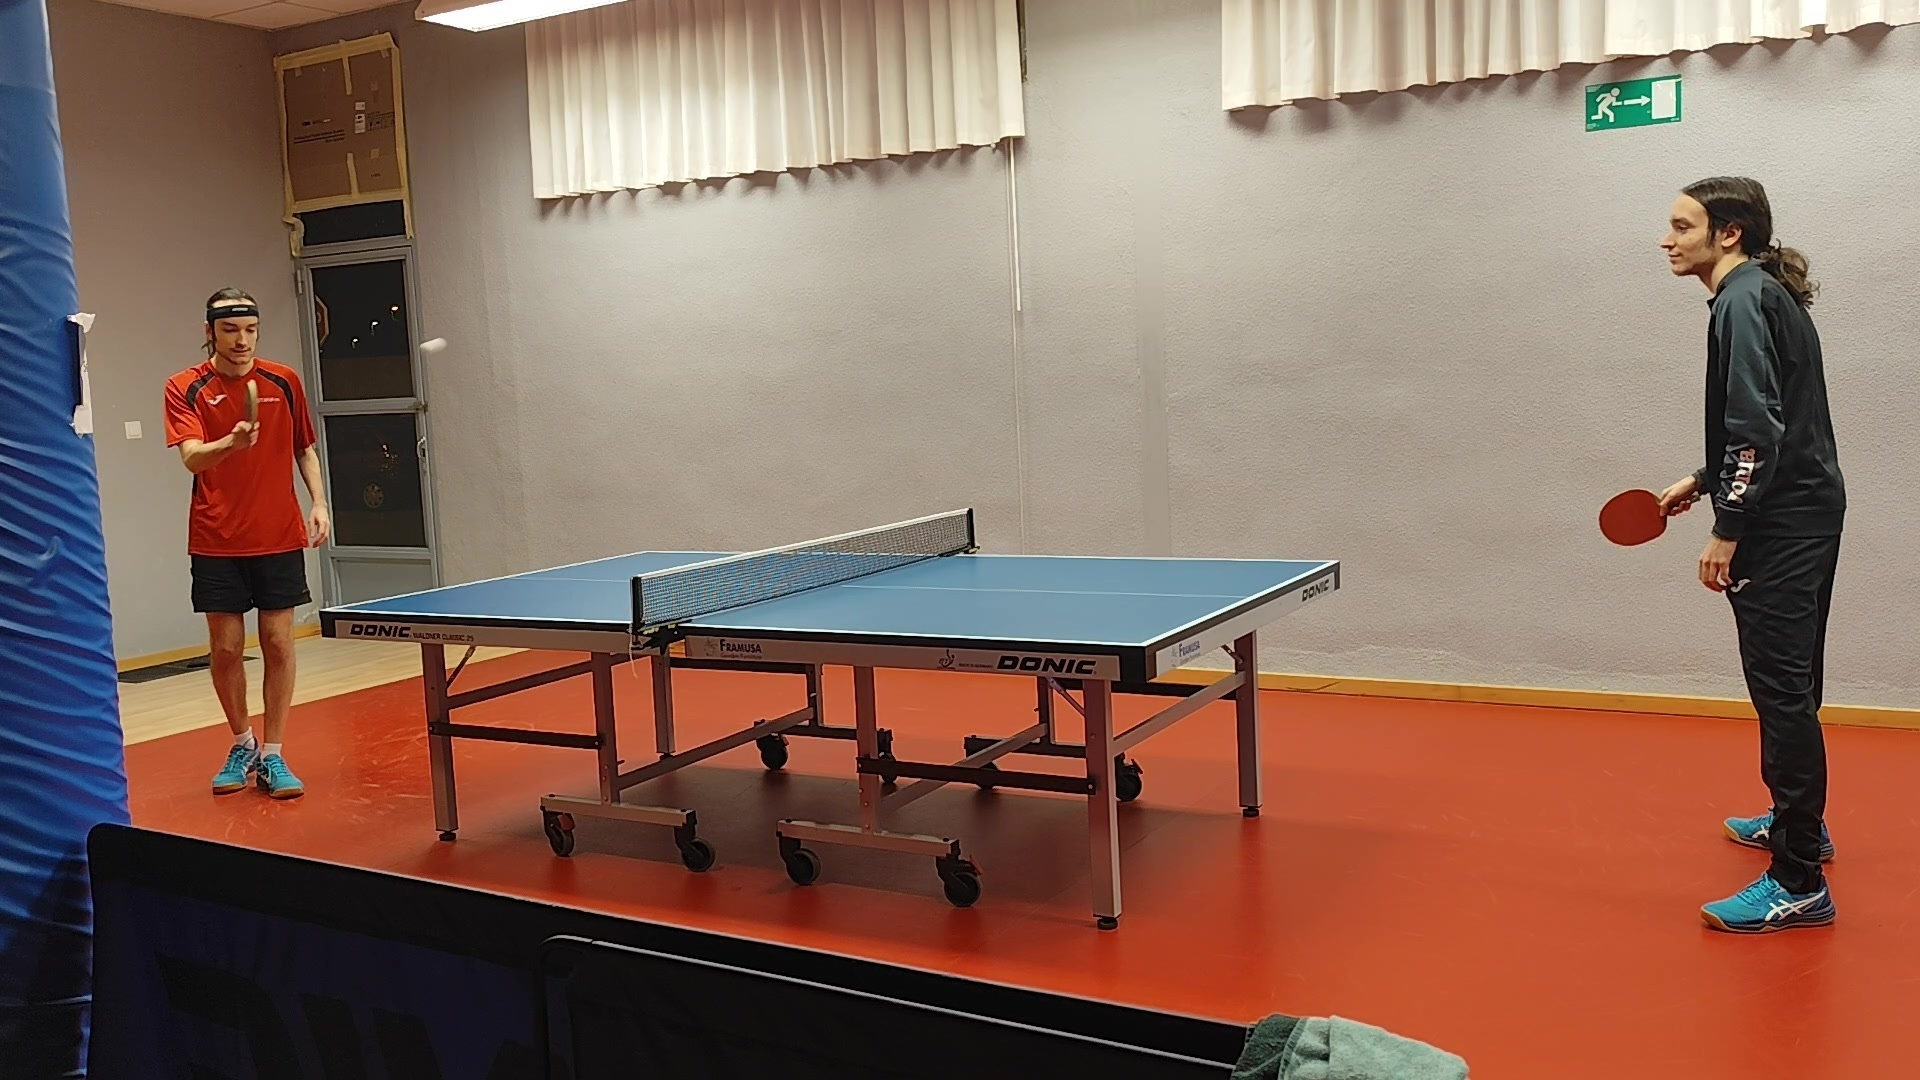

In [ ]:
import os
from IPython.display import Image, display
from google.colab.patches import cv2_imshow

# Directory where the segmentation results were saved
results_dir = '/content/runs/segment/segmentation_results'

if os.path.exists(results_dir):
    print(f"Displaying segmented images from: {results_dir}")
    # Get a list of all image files in the results directory
    segmented_image_files = [os.path.join(results_dir, f) for f in os.listdir(results_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    # Display up to 5 segmented images
    num_images_to_show = min(5, len(segmented_image_files))
    if num_images_to_show > 0:
        print(f"Showing {num_images_to_show} segmented images:")
        for i in range(num_images_to_show):
            display(Image(filename=segmented_image_files[i]))
    else:
        print("No segmented images found in the results directory.")
else:
    print(f"Results directory not found: {results_dir}. Please ensure the model.predict() step completed successfully and saved the output.")